This file merges data from different files in preparation for analyses

In [1]:
import pandas as pd
import numpy as np
import os

d = f"{os.getcwd()}/"
PATH_RAW = os.path.join(d, "..", "raw")   # raw inputs (downloads / intermediate CSVs)
PATH_DATA = os.path.join(d, "..", "data")    # processed modeling tables
# Output folder for model results (forecasts, performance tables)
PATH_OUTPUT = os.path.join(d, "..", "output")
# Create folder if it does not exist
os.makedirs(PATH_OUTPUT, exist_ok=True)
data_file = "data.csv"
meta_file = "meta.csv"

df = pd.read_csv(f"{PATH_DATA}/{data_file}" , index_col='date', parse_dates=True)

df.head(5)

,RGDP0000,UMBL0000,MLIA1001,MLIA1002,MLIA1003,MLIA1004,MLIA1000,MLIA0003,MLIA0002,MLIA0004,...,UGTR0021,UGTR0006,UGTR0001,REXC0001,REXC0002,XEMP0003,XIMP0003,XEMP0004,XIMP0004,UGTR0000
date,,,,,,,,,,,,,,,,,,,,,
2015-02-01,NaN,54304.080413,31890.278,135559.643,249451.351,116008.373,532909.645,52036.644,1501.182,14318.718,...,10.0,16.0,9.0,NaN,NaN,NaN,NaN,137.776543,25.294407,27.600
2015-03-01,376071.0,55526.300906,29976.701,127010.461,245889.630,112828.497,515705.289,56535.456,588.502,13734.467,...,9.0,19.0,15.0,NaN,NaN,NaN,NaN,143.741899,24.350571,27.050
2015-04-01,NaN,59615.749986,29459.217,130600.536,249975.925,124345.188,534380.866,45095.208,1278.866,14176.166,...,11.0,21.0,10.0,NaN,NaN,NaN,NaN,149.343548,27.563384,28.325
2015-05-01,NaN,59716.660777,31062.846,131010.962,250064.108,123469.817,535607.733,76705.413,1184.963,14060.821,...,11.0,20.0,15.0,NaN,NaN,NaN,NaN,177.942391,23.269631,28.225
2015-06-01,371294.0,67004.537620,33260.686,138340.931,252099.208,120679.419,544380.244,76448.591,564.249,13772.059,...,14.0,22.0,13.0,NaN,NaN,NaN,NaN,147.700706,42.666449,29.700


The dataset includes the output variable, GDP

<Axes: xlabel='date'>

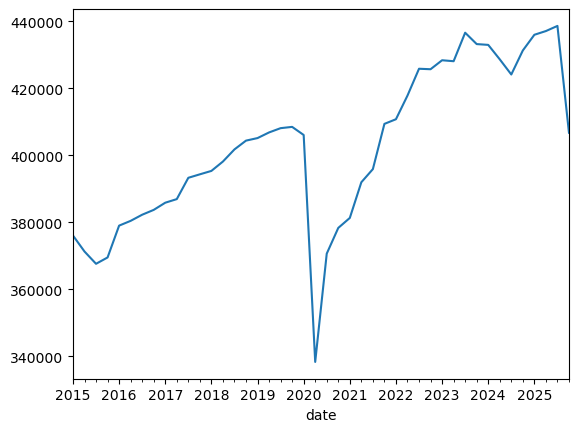

In [2]:
df['RGDP0000'].dropna().plot()

We wish to include **google trends** and **nighttime lights** data on our main data

First, let's keep only GDP.

In [3]:
df = df[['RGDP0000']].dropna()
df.head(5)

,RGDP0000
date,
2015-03-01,376071.0
2015-06-01,371294.0
2015-09-01,367625.0
2015-12-01,369521.0
2016-03-01,379026.0


## Google Trends

In [4]:
df_gt = pd.read_csv(f"{PATH_RAW}/gtrends.csv", parse_dates=True, index_col='date')
df_gt.head(5)

,gtrends_hotels_kingston_worldwide,gtrends_island_grill_jamaica,gtrends_pizza_hut_jamaica,gtrends_crave_jamaica,gtrends_uber_eats_jamaica,gtrends_doordash_jamaica,gtrends_samsung_jamaica,gtrends_apple_jamaica,gtrends_pricesmart_jamaica,gtrends_shoppers_fair_jamaica,...,gtrends_blue_mountains_jamaica,gtrends_treasure_beach_jamaica,gtrends_montego_bay_resorts_jamaica_worldwide,gtrends_jamaica_flights_jamaica,gtrends_toyota_jamaica,gtrends_linkedin_jamaica,gtrends_caribbeanjobs_com_jamaica,gtrends_kfc_jamaica,gtrends_burger_king_jamaica,gtrends_airbnb_jamaica_worldwide
date,,,,,,,,,,,,,,,,,,,,,
2004-01-01,45,0,0,0,0,0,34,0,0,0,...,0,0,0,0,65,0,0,0,0,0
2004-02-01,60,100,0,0,0,0,43,62,0,0,...,0,0,0,0,67,0,0,0,0,0
2004-03-01,72,0,0,0,0,0,40,0,0,0,...,0,0,0,0,62,0,0,0,0,0
2004-04-01,54,0,0,0,0,0,35,0,0,0,...,0,0,0,0,83,0,0,0,0,0
2004-05-01,66,0,0,0,0,0,42,0,0,0,...,0,0,0,0,71,0,0,0,0,0


Keep only data with enough observations

In [5]:
# Transform zeroes into np.nan
df_gt = df_gt.replace(0, np.nan)

# Keep only in the time period of the main database
df_gt = df_gt[df_gt.index>=df_gt.index.min()]

# drop columns with too many (75%) nan
df_gt = df_gt.dropna(axis=1, thresh=0.25 * len(df_gt))

# Generate a column with the average
df_gt['gt_mean'] = df_gt.mean(axis=1)

In [6]:
df_gt['gt_mean']

date
2004-01-01    46.000000
2004-02-01    59.875000
2004-03-01    53.000000
2004-04-01    49.166667
2004-05-01    65.200000
                ...    
2025-09-01    49.684211
2025-10-01    51.000000
2025-11-01    50.324324
2025-12-01    50.263158
2026-01-01    46.473684
Name: gt_mean, Length: 265, dtype: float64

<Axes: xlabel='date'>

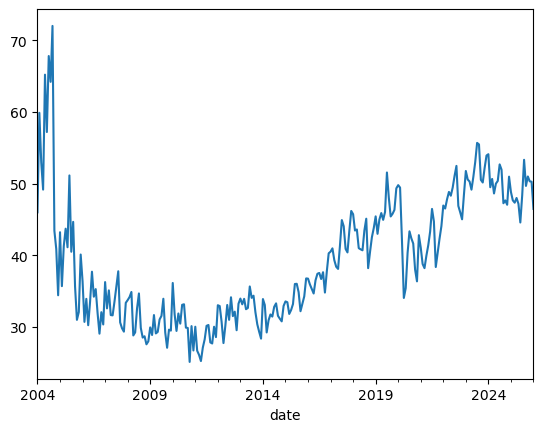

In [7]:
df_gt['gt_mean'].plot()

Keep only the mean variable

In [8]:
df_gt = df_gt[['gt_mean']]
df_gt.head(5)

,gt_mean
date,
2004-01-01,46.000000
2004-02-01,59.875000
2004-03-01,53.000000
2004-04-01,49.166667
2004-05-01,65.200000


## Add NTL data

1. Load data_ntl_shape.csv

2. Address seasonality

3. Use the resample function to transform into quarterly

# Merge Together

1. Add the NTL dataframe

In [9]:
data = pd.concat([ df , df_gt] , axis=1).sort_index()
data.tail(5)

,RGDP0000,gt_mean
date,,
2025-09-01,438665.0,49.684211
2025-10-01,NaN,51.000000
2025-11-01,NaN,50.324324
2025-12-01,406765.0,50.263158
2026-01-01,NaN,46.473684


## Preprocessing

Apply seasonal adjustment, and growth-rate transformation
Resample to quarterly
Visualize

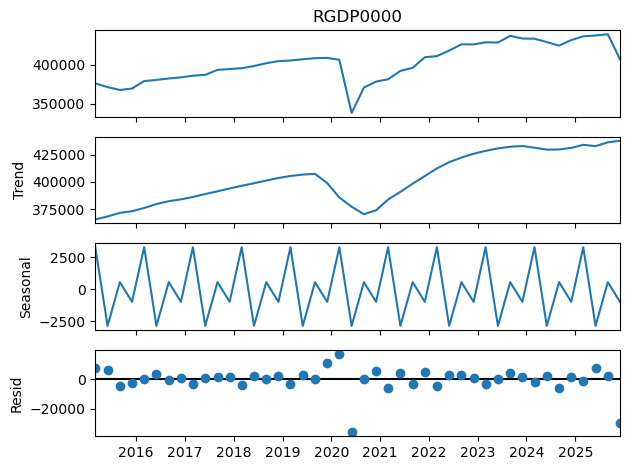

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose
seasonal_decompose(data["RGDP0000"].dropna(how='all', axis=0), model='additive', extrapolate_trend='freq', period=4).plot();

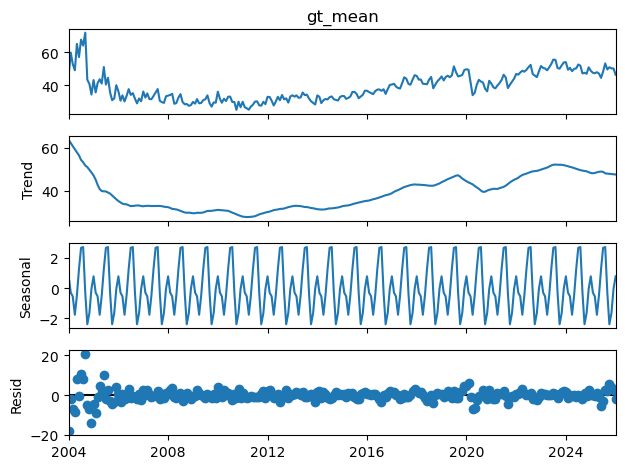

In [14]:
seasonal_decompose(data["gt_mean"].dropna(how='all', axis=0), model='additive', extrapolate_trend='freq', period=12).plot();

In [ ]:
'''
# GDP Is already seasonally adjusted so we will omit this step.
data["RGDP0000_trend"] = seasonal_decompose(                                                          
      data["RGDP0000"].dropna(), model='additive', extrapolate_trend='freq', period=4                 
  ).trend
'''
  
data["gt_mean_trend"] = seasonal_decompose(                                                          
      data["gt_mean"].dropna(), model='additive', extrapolate_trend='freq', period=12                 
  ).trend

data

,RGDP0000,gt_mean,RGDP0000_trend,gt_mean_trend
date,,,,
2004-01-01,NaN,46.000000,NaN,63.553779
2004-02-01,NaN,59.875000,NaN,62.114390
2004-03-01,NaN,53.000000,NaN,60.675001
2004-04-01,NaN,49.166667,NaN,59.235612
2004-05-01,NaN,65.200000,NaN,57.796223
...,...,...,...,...
2025-09-01,438665.0,49.684211,436237.0500,47.977219
2025-10-01,NaN,51.000000,NaN,47.871078
2025-11-01,NaN,50.324324,NaN,47.764938


<Axes: xlabel='date'>

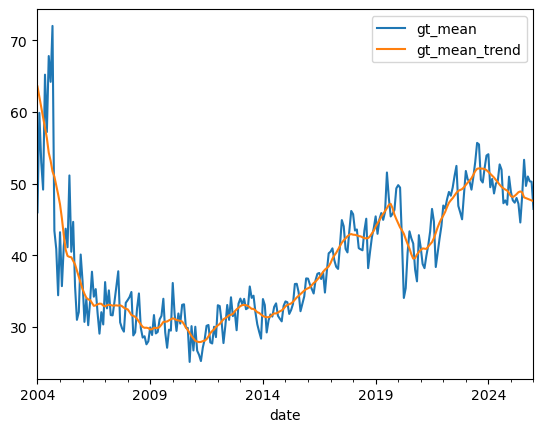

In [17]:
data[['gt_mean','gt_mean_trend']].dropna().plot()

In [ ]:
# Keep only seasonally adjusted
data = data[[ col for col in data.columns if "trend" in col or "RGDP" in col ]]
# Eliminate _trend suffix
data.columns = [ col.replace("_trend","") for col in data.columns ]
data.head(5)

,RGDP0000,gt_mean
date,,
2004-01-01,NaN,63.553779
2004-02-01,NaN,62.114390
2004-03-01,NaN,60.675001
2004-04-01,NaN,59.235612
2004-05-01,NaN,57.796223


In [19]:
# this loop calculates growth rates
for column in data.columns:                                                                           
    data[column + "_gr"] = data[column].dropna().pct_change() * 100


C:\Users\guerr\AppData\Local\Temp\ipykernel_8740\1127114613.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[column + "_gr"] = data[column].dropna().pct_change() * 100


In [20]:
data[[ col for col in data.columns if "RGDP" in col  ]].dropna().tail(10)

,RGDP0000,RGDP0000_gr
date,,
2023-09-01,432177.8750,0.351172
2023-12-01,432821.5000,0.148926
2024-03-01,431331.3750,-0.344282
2024-06-01,429533.2500,-0.416878
2024-09-01,429672.2500,0.032361
2024-12-01,431105.6250,0.333597
2025-03-01,433975.0000,0.665585
2025-06-01,432717.1250,-0.289850
2025-09-01,436237.0500,0.813447


In [21]:
data[[ col for col in data.columns if "gt" in col  ]].dropna().tail(10)

,gt_mean,gt_mean_gr
date,,
2025-04-01,48.529210,0.497279
2025-05-01,48.804785,0.567854
2025-06-01,48.911530,0.218718
2025-07-01,48.783270,-0.262228
2025-08-01,48.083359,-1.434736
2025-09-01,47.977219,-0.220742
2025-10-01,47.871078,-0.221231
2025-11-01,47.764938,-0.221721
2025-12-01,47.658798,-0.222214


In [22]:
# Keep only growth rates
data = data[[ col for col in data.columns if "gr" in col  ]]
# Eliminate _gr suffix
data.columns = [ col.replace("_gr","") for col in data.columns ]

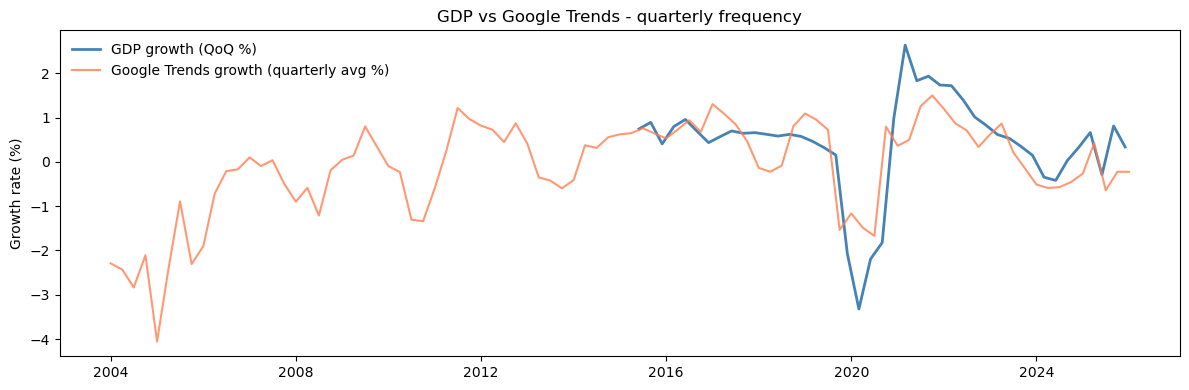

In [24]:
# Google Trends resampled to quarterly (mean within each quarter)
gt_quarterly = data["gt_mean"].resample("QS").mean()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(data["RGDP0000"].dropna().index, data["RGDP0000"].dropna(),
        color="steelblue", linewidth=2, label="GDP growth (QoQ %)")
ax.plot(gt_quarterly.dropna().index, gt_quarterly.dropna(),
        color="coral", linewidth=1.5, alpha=0.8, label="Google Trends growth (quarterly avg %)")

ax.set_ylabel("Growth rate (%)")
ax.legend(frameon=False)
ax.set_title("GDP vs Google Trends - quarterly frequency")

plt.tight_layout()
plt.show()